In [1]:
import numpy as np 
from fun_nearealtime_RTM import FY4A_calinu
import os
import matplotlib.pyplot as plt

C01
C02
C03
C04
C05
C06


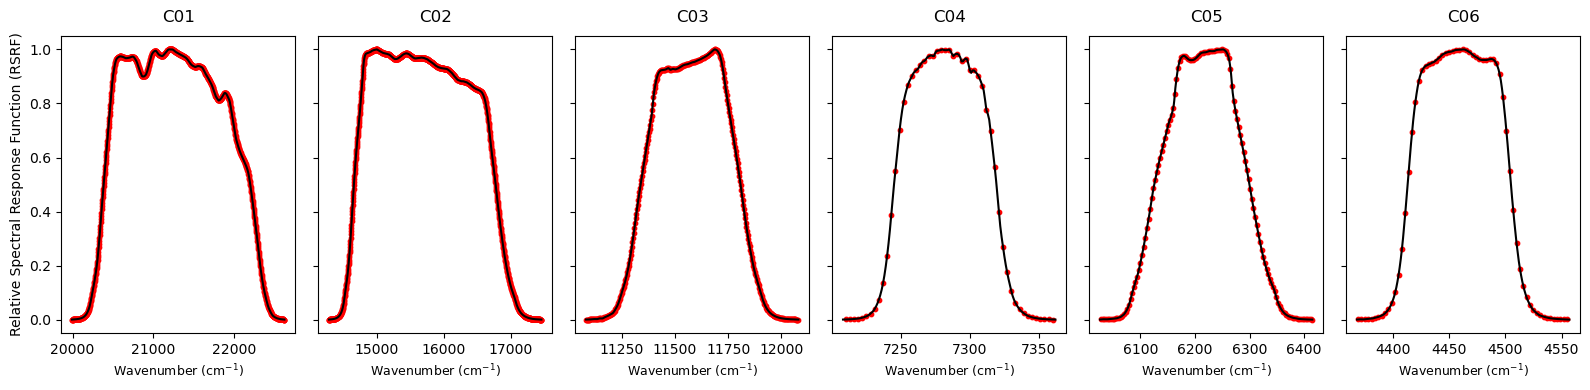

In [ ]:
file_dir='./FY4A_data/'
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
nu0 = np.arange(2500, 35000, 3)  # Wavenumber grid
nu_channels = FY4A_calinu(nu0, channels, "./FY4A_data/", dnu=3)
fdir = "./FY4A_data/" + 'LUT/'
# figure size 12 * 4
fig, axes = plt.subplots(1, len(channels), figsize=(16, 4), sharey=True)
LINE_LABEL = 'Continuous SRF'  # '- means srf'
SCATTER_LABEL = 'RTM Wavenumbers' # 'scatter means rtm nu'
for i, channel in enumerate(channels):
    print(channel)
    # load calibration data : Spectral Response Func
    channel_number = int(channel[-2:])
    sensor = 'GOES16'
    if sensor == 'GOES16':
        dirpath = file_dir + 'abi_calibration/'
        channel_srf = os.path.join(dirpath,
                                    'GOES-R_ABI_PFM_SRF_CWG_ch{:d}.txt'.format(channel_number))

    calibration = np.genfromtxt(channel_srf, skip_header=2)
    calibration_nu = calibration[:, 1]  # cm-1
    calibration_srf = calibration[:, 2]  # relative SRF [-]
    nu_channel = goes_calinu(nu0, [channel], file_dir, dnu=3)
    calibration_nu = calibration_nu[::-1]
    calibration_srf = calibration_srf[::-1]
    srf = np.interp(nu_channel, calibration_nu, calibration_srf)
    nu_idx = np.nonzero(np.isin(nu_channels, nu_channel))[0]  # fixed 1 April.


    ax = axes[i]
    # 1. Plot continuous SRF (Line plot)
    line_plot, = ax.plot(
        calibration_nu,
        calibration_srf,
        color='k',
        label=LINE_LABEL
    )

    # 2. Plot RTM Wavenumbers (Scatter plot)
    scatter_plot = ax.scatter(
        nu_channel,
        srf,
        s=10, # Adjusted size for clarity
        color='red',
        marker='o',
        label=SCATTER_LABEL
    )
    ax.set_xlabel('Wavenumber ($\mathrm{cm^{-1}}$)', fontsize=9)
    ax.set_title(f'{channel}', fontsize=12, pad=10) # Set channel title above the plot

axes[0].set_ylabel('Relative Spectral Response Function (RSRF)', fontsize=10)


# Adjust layout to prevent overlap and make room for legend
plt.tight_layout() # Make room for the legend at the bottom
plt.show()

# FY4A Satellite data exploration

In [2]:
import pandas as pd
from fun_nearealtime_RTM import *

## load 

In [5]:
ls

AOD_correction/
AngDistLUT.py
DrLi_gorgeous_plotlib.py
FY4A_data/
FY4A_validation/
FY4_pixel_angle_distribution-new.ipynb
LBL_funcs.py
LBL_funcs_fullSpectrum.py*
LBL_funcs_getHitran.py*
LBL_funcs_getHitran_SW.py
LBL_funcs_inclined.py*
LBL_funcs_longwave.py*
LBL_funcs_plotting.py
LBL_funcs_shortwave.c
LBL_funcs_shortwave.cpython-310-darwin.so*
LBL_funcs_shortwave.cpython-310-x86_64-linux-gnu.so*
LBL_funcs_shortwave.pyx*
LBL_funcs_utl.py
LUT_parameters_GOES_us.txt
README.md
RTM/
Rich_POA.py
SCOPE_func.py
SWRTM_Predictor.py
Sat_Preprocessing/
UW_angle_distribution.ipynb
__pycache__/
aod_codes.py
build/
data/
deltaM.py
figures/
fun_nearealtime_RTM.py
gethapi.py
gifmaker.ipynb
half_year_satellite_clearday_analysis.ipynb
hapi.py*
main_GradientDescent.ipynb
main_SW_clearsky.py
main_SW_scope_nearealtime.py
main_fullSpectrum.ipynb
main_longwave.ipynb
main_shortwave.ipynb
main_shortwave.py
mcd43a1_albedo.py
mini_test/
results_shortwave/
sat_results_test.ipynb
setup.py
setup_aod.py
spectral_coeff

In [15]:
import pandas as pd

sites = ['FQA']#'BON']#, 'PSU', 'SXF']
sky = 'clear'

all_dfs = []

for s in sites:
    # 1. Read file for the specific site
    # file_path = './Sat_Preprocessing/Ground/preprocessed/{}_{}.h5'.format(s, sky)
    # df_temp = pd.read_hdf(file_path, key='df')
    file_path = 'FY4A_data/{}_radiance_satellite_{}.csv'.format(s, sky)
    df_temp = pd.read_csv(file_path, parse_dates=['Time'])
    
    # 2. Print size
    print(f"Site {s} size: {len(df_temp)} rows, {df_temp.shape[1]} columns")
    
    # 3. Add the site column (Uncommented and active)
    df_temp['site'] = s 
    
    all_dfs.append(df_temp)

# 4. Combine all into one
df_combined = pd.concat(all_dfs)

print("-" * 30)
print(f"Total Combined size: {len(df_combined)} rows")

# Check that the site column was created correctly
print("\nData distribution by site:")
print(df_combined['site'].value_counts())

Site FQA size: 775 rows, 44 columns
------------------------------
Total Combined size: 775 rows

Data distribution by site:
site
FQA    775
Name: count, dtype: int64


In [16]:
df_combined[df_combined.index.month == 3]['T'].describe()

AttributeError: 'RangeIndex' object has no attribute 'month'

In [18]:
df_combined.set_index('Time', inplace=True)

In [19]:
df_combined[df_combined.index.month != 3]['T_a'].describe()

count    722.000000
mean     292.901876
std       10.345259
min      263.490000
25%      284.125000
50%      294.450000
75%      301.507500
max      311.330000
Name: T_a, dtype: float64

In [21]:
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
print(df_combined.columns)
df_combined = df_combined[df_combined['T_a']>283]
df_combined = df_combined[(df_combined[channels] >= 0).all(axis=1)].copy()

Index(['index', 'ghi', 'Sun_Zen', 'Sun_Azi', 'ghi_clear', 'T_a', 'RH', 'C01',
       'C02', 'C03', 'C04', 'C05', 'C06', 'Sat_Azi', 'Sat_Zen', 'Sun_Azi_sat',
       'Sun_Gli', 'ele', 'Abdo_C01_p0', 'Abdo_C01_p1', 'Abdo_C01_p2',
       'Abdo_C02_p0', 'Abdo_C02_p1', 'Abdo_C02_p2', 'Abdo_C03_p0',
       'Abdo_C03_p1', 'Abdo_C03_p2', 'Abdo_C05_p0', 'Abdo_C05_p1',
       'Abdo_C05_p2', 'Abdo_C06_p0', 'Abdo_C06_p1', 'Abdo_C06_p2', 'BSA_C01',
       'WSA_C01', 'BSA_C02', 'WSA_C02', 'BSA_C03', 'WSA_C03', 'BSA_C05',
       'WSA_C05', 'BSA_C06', 'WSA_C06', 'site'],
      dtype='object')


In [32]:
def plot_zen_uw(site_zen, Rc_rtm_df, channels, VAR, CODfromWhom, figlabel=None):

    font = 13
    fontfml = 'Times New Roman'
    plt.rcParams['font.size'] = font
    plt.rcParams['font.family'] = fontfml
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = fontfml
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

    fig = plt.figure(figsize=(12, 6))
    gs1 = gridspec.GridSpec(2, 3)
    gs1.update(wspace=0.18, hspace=0.15, right=0.9)

    zen_values = site_zen if isinstance(site_zen, (np.ndarray, list)) else site_zen.values
    norm = plt.Normalize(zen_values.min(), zen_values.max()) #10, 60)   # 
    cmap = "viridis"
    # Create the ScalarMappable for the Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    mu  = site_zen #np.cos(np.deg2rad(site_zen))
    x = mu.values if hasattr(mu, 'values') else mu

    for idx, ch in enumerate(channels):
        ax = fig.add_subplot(gs1[idx // 3, idx % 3])
        y = Rc_rtm_df[ch].values


        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())

        sns.scatterplot(
            x=x, y=y, ax=ax,
            hue=zen_values,       # Color by Zenith
            hue_norm=norm,        # Force consistent color scaling
            palette=cmap,
            legend=False,         # Disable individual legends
            edgecolor='w', s=30, alpha=0.8
        )

        # ax.plot([min_val * 0.9, max_val * 1.1], [min_val * 0.9, max_val * 1.1],
        #         color='gray', linestyle='--', linewidth=1.5)

        # Axis Limits Specifics
        # if ch == 'C04':
        #     ax.set_xlim(0, max_val * 1.1)
        #     ax.set_ylim(0, max_val * 1.1)
        # else:
        #     # Default limits logic
        #     ax.set_xlim(min_val * 0.9, max_val * 1.1)
        #     ax.set_ylim(min_val * 0.9, max_val * 1.1)


        if ch in ['C02','C05','C06']:
            text_x, text_y = 0.55, 0.42
        else:
            text_x, text_y = 0.02, 0.98

        if idx == 4:
            #ax.set_xlabel(r'$\cos(\theta_z)$', fontsize=font, family=fontfml)
            ax.set_xlabel(f'{VAR}', fontsize=font, family=fontfml)
        if idx in [0, 1, 2]:
            ax.set_xticklabels([])
            #$ax.set_xlabel('')
        # ax.set_xticks(ax.get_yticks()) # Ensure square ticks if desired
        ax.grid(color='grey', linestyle='--', linewidth=0.5)
        ax.set_title(f'{ch}', fontsize=font, family=fontfml,pad=2)

    fig.text(0.13, 0.91, f'n: {len(mu)}',
             fontsize=12-0.5, weight='bold', ha='left', va='top')
    # --- 4. Global Y-Label ---
    fig.supylabel(f'{CODfromWhom} UW reflectance',
                  fontsize=font, family=fontfml,
                  ha='center',  # 'center' alignment is usually easier to control than 'left'
                  va='center',
                  x=0.08)

    # --- 5. Add Global Colorbar ---
    # Create a new axes for the colorbar on the right side of the figure
    # [left, bottom, width, height] in figure coordinate fractions
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(f'{VAR}', rotation=270, labelpad=20, fontsize=font, family=fontfml)
    #cbar.set_label(f'Solar Zenith Angle [°]', rotation=270, labelpad=20, fontsize=font, family=fontfml)

    figname = './FY4A_validation/clearsky/' + f'UW_6ch_clearsky_{CODfromWhom}_{VAR}_FQA.png'
    fig.savefig(figname, dpi=600, bbox_inches='tight')
    plt.show()

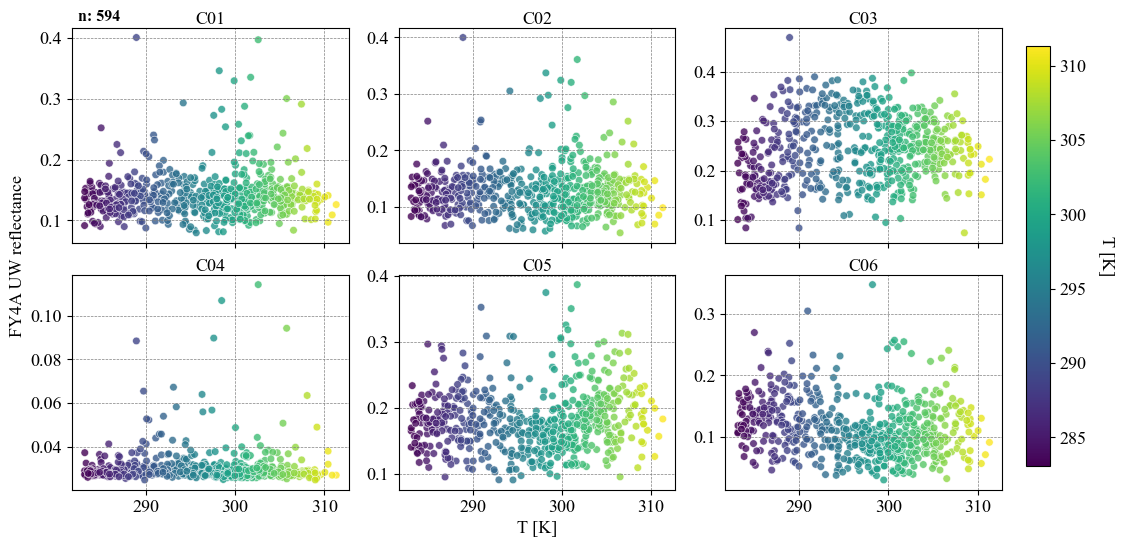

In [39]:
VAR = 'T [K]'
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
sat_rad = df_combined[channels]

CODfromwho = 'FY4A'
plot_zen_uw(df_combined['T_a'], sat_rad, channels, VAR, CODfromwho)

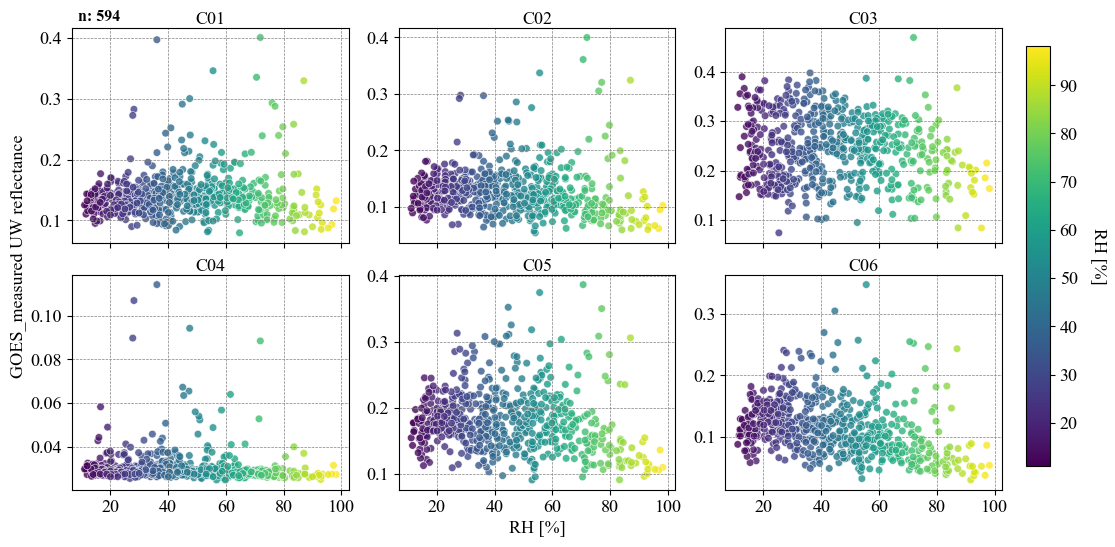

In [38]:
VAR = 'RH [%]'
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
sat_rad = df_combined[channels]

CODfromwho = 'GOES_measured'
plot_zen_uw(df_combined['RH'], sat_rad, channels, VAR, CODfromwho)

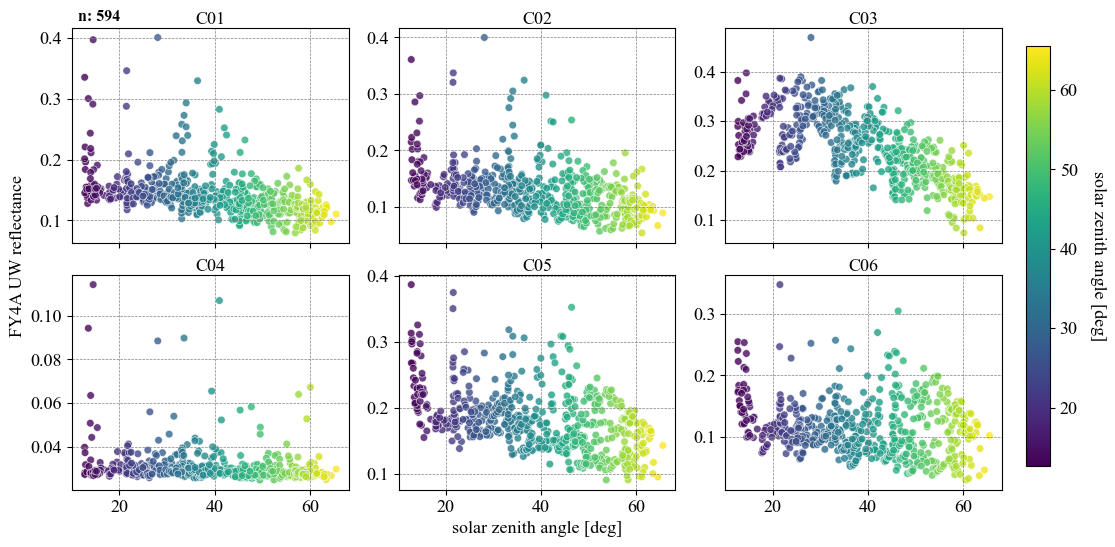

In [41]:
VAR = 'solar zenith angle [deg]'
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
sat_rad = df_combined[channels]

CODfromwho = 'FY4A'
plot_zen_uw(df_combined['Sun_Zen'], sat_rad, channels, VAR, CODfromwho)

In [42]:
df_combined.index

DatetimeIndex(['2021-01-12 06:00:00', '2021-01-13 04:00:00',
               '2021-01-14 05:00:00', '2021-01-14 06:00:00',
               '2021-01-18 05:00:00', '2021-01-18 06:00:00',
               '2021-01-18 07:00:00', '2021-01-30 04:00:00',
               '2021-01-30 06:00:00', '2021-01-30 07:00:00',
               ...
               '2021-12-14 05:00:00', '2021-12-14 06:00:00',
               '2021-12-20 03:00:00', '2021-12-20 04:00:00',
               '2021-12-20 05:00:00', '2021-12-20 06:00:00',
               '2021-12-21 03:00:00', '2021-12-21 04:00:00',
               '2021-12-21 05:00:00', '2021-12-21 06:00:00'],
              dtype='datetime64[ns]', name='Time', length=594, freq=None)

## month

In [43]:
df_combined.index.month.unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='Time')

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Pass 'df_combined.index' as the new argument 'dt_index'
def plot_zen_uw(site_zen, Rc_rtm_df, channels, VAR, CODfromWhom, dt_index):

    font = 13
    fontfml = 'Times New Roman'
    plt.rcParams['font.size'] = font
    plt.rcParams['font.family'] = fontfml
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = fontfml
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

    fig = plt.figure(figsize=(12, 6))
    gs1 = gridspec.GridSpec(2, 3)
    gs1.update(wspace=0.18, hspace=0.15, right=0.9)

    # --- 1. Prepare Data ---
    # X-axis data (Cosine Zenith)
    mu = np.cos(np.deg2rad(site_zen))
    x = mu.values if hasattr(mu, 'values') else mu
    
    # Color data (Months)
    hue_values = dt_index.month #dt_index.dt.month
    #dt_index.month 
    
    # --- 2. Color Mapping Setup ---
    # Use 'jet' or 'viridis' (jet is common for separating seasons/months)
    cmap = "viridis" 
    min_month = hue_values.min()
    max_month = hue_values.max()
    norm = plt.Normalize(min_month, max_month)
    
    # Create the ScalarMappable for the Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for idx, ch in enumerate(channels):
        ax = fig.add_subplot(gs1[idx // 3, idx % 3])
        y = Rc_rtm_df[ch].values

        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())

        sns.scatterplot(
            x=x, y=y, ax=ax,
            hue=hue_values,       # Color by Month
            hue_norm=norm,        
            palette=cmap,
            legend=False,         
            edgecolor='w', s=30, alpha=0.8
        )

        # Labels and Formatting
        if ch in ['C02','C05','C06']:
            text_x, text_y = 0.55, 0.42
        else:
            text_x, text_y = 0.02, 0.98

        if idx == 4:
            ax.set_xlabel(r'$\cos(\theta_z)$', fontsize=font, family=fontfml)
        if idx in [0, 1, 2]:
            ax.set_xticklabels([])

        ax.grid(color='grey', linestyle='--', linewidth=0.5)
        ax.set_title(f'{ch}', fontsize=font, family=fontfml, pad=2)

    fig.text(0.13, 0.91, f'n: {len(mu)}',
             fontsize=12-0.5, weight='bold', ha='left', va='top')
             
    fig.supylabel(f'{CODfromWhom} UW reflectance',
                  fontsize=font, family=fontfml,
                  ha='center', va='center', x=0.07)

    # --- 3. Add Global Colorbar (Month) ---
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cax)
    
    # Force integer ticks for months (e.g. 3, 4, 5, 6)
    tick_locator = ticker.MaxNLocator(integer=True)
    cbar.locator = tick_locator
    cbar.update_ticks()
    
    cbar.set_label(f'{VAR}', rotation=270, labelpad=20, fontsize=font, family=fontfml)

    figname = './FY4A_validation/clearsky/' + f'UW_6ch_clearsky_{CODfromWhom}_{VAR}_sample.png'
    fig.savefig(figname, dpi=600, bbox_inches='tight')
    plt.show()

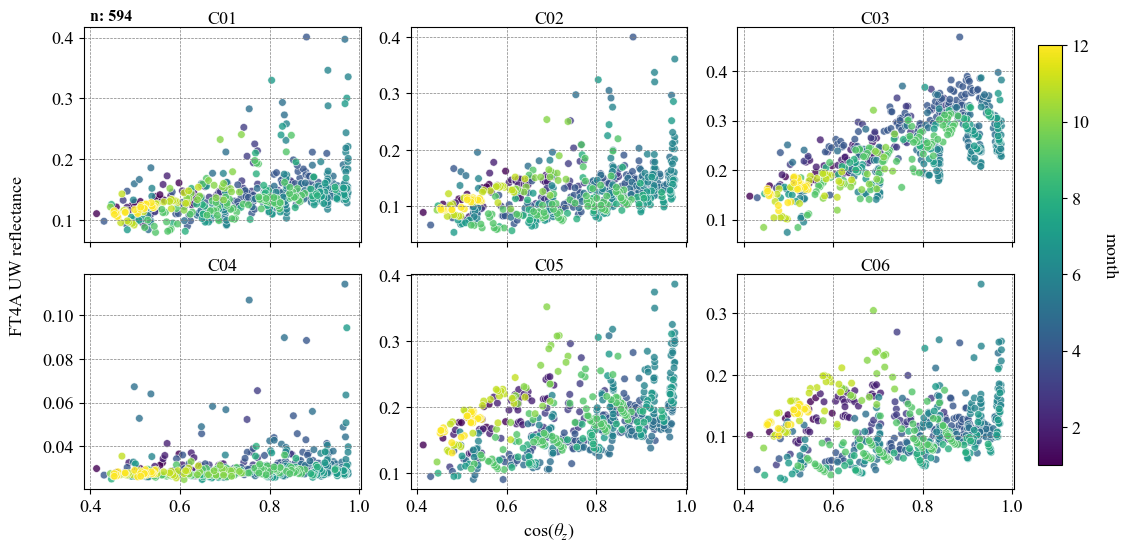

In [49]:
plot_zen_uw(site_zen=df_combined['Sun_Zen'], 
            Rc_rtm_df=df_combined, 
            channels=['C01', 'C02', 'C03', 'C04', 'C05', 'C06'], 
            VAR='month', 
            CODfromWhom='FT4A', 
            #dt_index = df_combined[''].values,
            dt_index=df_combined.index,  # <--- Pass the index here
            )

# data filter and saving

In [56]:
df_combined.columns

Index(['Time', 'index', 'ghi', 'Sun_Zen', 'Sun_Azi', 'ghi_clear', 'T_a', 'RH',
       'C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'Sat_Azi', 'Sat_Zen',
       'Sun_Azi_sat', 'Sun_Gli', 'ele', 'Abdo_C01_p0', 'Abdo_C01_p1',
       'Abdo_C01_p2', 'Abdo_C02_p0', 'Abdo_C02_p1', 'Abdo_C02_p2',
       'Abdo_C03_p0', 'Abdo_C03_p1', 'Abdo_C03_p2', 'Abdo_C05_p0',
       'Abdo_C05_p1', 'Abdo_C05_p2', 'Abdo_C06_p0', 'Abdo_C06_p1',
       'Abdo_C06_p2', 'BSA_C01', 'WSA_C01', 'BSA_C02', 'WSA_C02', 'BSA_C03',
       'WSA_C03', 'BSA_C05', 'WSA_C05', 'BSA_C06', 'WSA_C06', 'site',
       'month_bin', 'Ta_bin', 'RH_bin', 'Zen_bin'],
      dtype='object')

In [59]:
# df_combined = df_combined[['C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'Sun_Zen', 'local_Zen',
#        'rela_azi', 'zen', 'dw_solar', 'direct_n', 'diffuse', 'dw_ir', 'T', 'RH','site']]
#df_combined = df_combined[df_combined['direct_n']>0]
df_combined.dropna(inplace=True)
df_combined.index.name = 'Time'
#df_combined = df_combined.reset_index()

df_combined = df_combined[df_combined['Sun_Zen']<60]


# Define the columns you want to filter
cols = ['T_a', 'RH', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']

# Loop through each column and filter
for col in cols:
    # Calculate the 0.5% and 99.5% quantiles
    lower = df_combined[col].quantile(0.005)
    upper = df_combined[col].quantile(0.995)
    
    # Keep only values within this range
    df_combined = df_combined[
        (df_combined[col] >= lower) & 
        (df_combined[col] <= upper)
    ]

print(f"Remaining rows after filtering: {len(df_combined)}")

#df_combined.to_csv('GOES_tool/data/SXF_clear_sky_data.csv', index=False)

Remaining rows after filtering: 512


### sample for test

In [74]:
df_combined.set_index('Time', inplace=True)
# Select months 4 through 10 (inclusive)
df_combined = df_combined[(df_combined.index.month >= 4) & (df_combined.index.month <= 10)].copy()

In [76]:
# 1. Ensure Time is datetime to extract Month
df_combined.index.name = 'Time'
df_combined = df_combined.reset_index()
df_combined['Time'] = pd.to_datetime(df_combined['Time'])

# 2. Create "Bins" for your continuous variables
# We divide the data into 4 or 5 chunks for each variable.
# pd.cut creates bins based on values (uniform spacing).
df_combined['month_bin'] = df_combined['Time'].dt.month
df_combined['Ta_bin']    = pd.cut(df_combined['T_a'], bins=5)       # 5 Temperature zones
df_combined['RH_bin']    = pd.cut(df_combined['RH'], bins=5)      # 5 Humidity zones
df_combined['Zen_bin']   = pd.cut(df_combined['Sun_Zen'], bins=6) # 5 Solar angles

# 3. Stratified Sampling
# Group by all bins and take 1 random sample from each valid combination.
# This forces the model to pick points that are distinct from each other.
sampled_df = df_combined.groupby(['month_bin', 'Ta_bin', 'RH_bin', 'Zen_bin']).apply(
    lambda x: x.sample(1, random_state=42)
).reset_index(drop=True)

# 4. Cleanup (remove the temporary bin columns)
sampled_df = sampled_df.drop(columns=['month_bin', 'Ta_bin', 'RH_bin', 'Zen_bin'])

print(f"Original size: {len(df_combined)}")
print(f"Sampled size:  {len(sampled_df)}")

Original size: 406
Sampled size:  189


In [77]:
def plot_zen_uw(site_zen, Rc_rtm_df, channels, VAR, CODfromWhom, dt_index):

    font = 13
    fontfml = 'Times New Roman'
    plt.rcParams['font.size'] = font
    plt.rcParams['font.family'] = fontfml
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = fontfml
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

    fig = plt.figure(figsize=(12, 6))
    gs1 = gridspec.GridSpec(2, 3)
    gs1.update(wspace=0.18, hspace=0.15, right=0.9)

    # --- 1. Prepare Data ---
    # X-axis data (Cosine Zenith)
    mu = np.cos(np.deg2rad(site_zen))
    x = mu.values if hasattr(mu, 'values') else mu
    
    # Color data (Months)
    hue_values = dt_index.dt.month
    #dt_index.month 
    
    # --- 2. Color Mapping Setup ---
    # Use 'jet' or 'viridis' (jet is common for separating seasons/months)
    cmap = "viridis" 
    min_month = hue_values.min()
    max_month = hue_values.max()
    norm = plt.Normalize(min_month, max_month)
    
    # Create the ScalarMappable for the Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for idx, ch in enumerate(channels):
        ax = fig.add_subplot(gs1[idx // 3, idx % 3])
        y = Rc_rtm_df[ch].values

        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())

        sns.scatterplot(
            x=x, y=y, ax=ax,
            hue=hue_values,       # Color by Month
            hue_norm=norm,        
            palette=cmap,
            legend=False,         
            edgecolor='w', s=30, alpha=0.8
        )

        # Labels and Formatting
        if ch in ['C02','C05','C06']:
            text_x, text_y = 0.55, 0.42
        else:
            text_x, text_y = 0.02, 0.98

        if idx == 4:
            ax.set_xlabel(r'$\cos(\theta_z)$', fontsize=font, family=fontfml)
        if idx in [0, 1, 2]:
            ax.set_xticklabels([])

        ax.grid(color='grey', linestyle='--', linewidth=0.5)
        ax.set_title(f'{ch}', fontsize=font, family=fontfml, pad=2)

    fig.text(0.13, 0.91, f'n: {len(mu)}',
             fontsize=12-0.5, weight='bold', ha='left', va='top')
             
    fig.supylabel(f'{CODfromWhom} UW flux [W/(m$^2$/sr)]',
                  fontsize=font, family=fontfml,
                  ha='center', va='center', x=0.07)

    # --- 3. Add Global Colorbar (Month) ---
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cax)
    
    # Force integer ticks for months (e.g. 3, 4, 5, 6)
    tick_locator = ticker.MaxNLocator(integer=True)
    cbar.locator = tick_locator
    cbar.update_ticks()
    
    cbar.set_label(f'{VAR}', rotation=270, labelpad=20, fontsize=font, family=fontfml)

    figname = './FY4A_validation/clearsky/' + f'UW_6ch_clearsky_{CODfromWhom}_{VAR}_sample.png'
    fig.savefig(figname, dpi=600, bbox_inches='tight')
    plt.show()

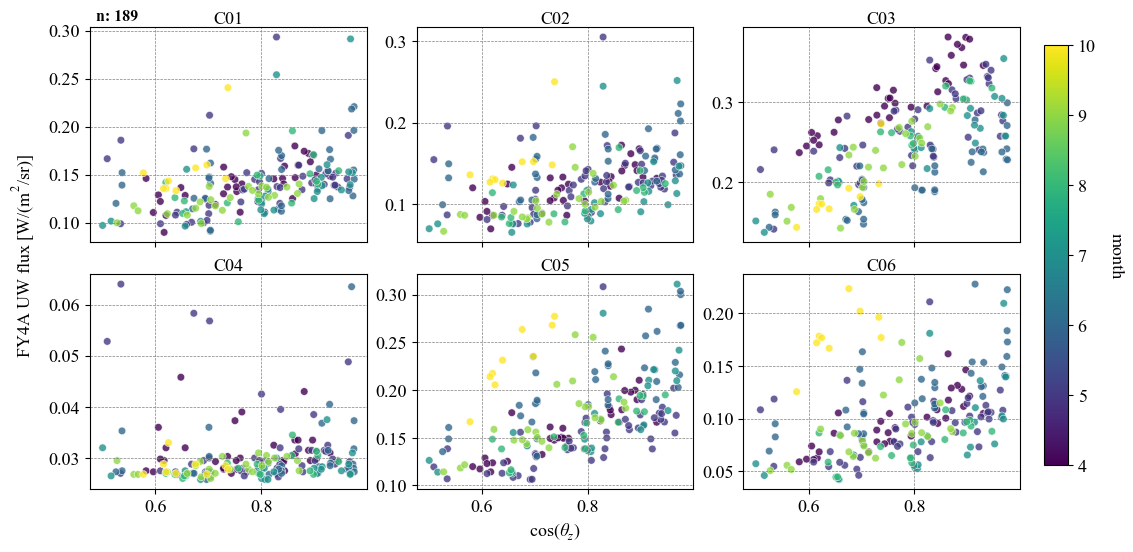

In [79]:
plot_zen_uw(site_zen=sampled_df['Sun_Zen'], 
            Rc_rtm_df=sampled_df, 
            channels=['C01', 'C02', 'C03', 'C04', 'C05', 'C06'], 
            VAR='month', 
            CODfromWhom='FY4A', 
            #dt_index = df_combined[''].values,
            dt_index=sampled_df['Time'],  # <--- Pass the index here
            )

In [ ]:
# Define the mapping: {'Old Name': 'New Name'}
rename_map = {
    'zen': 'Site_zen',
    'dw_solar': 'Site_dsw',
    'T': 'temp',
    'RH': 'rh'
}
sampled_df = sampled_df.rename(columns=rename_map)
sampled_df.to_csv('./FY4A_data/sampled_SXF_satdata_clearsky.csv', index=False)

In [72]:
filename="./GOES_tool/SURFRAD/SURFRAD_sxf_2019_full_year.csv"

df_surfrad = pd.read_csv(filename)
df_surfrad['Time'] = pd.to_datetime(df_surfrad['Time'])
df_surfrad = df_surfrad.set_index('Time')
df_surfrad = df_surfrad.resample("5min", label="right").mean()
#df_surfrad.reset_index(inplace=True)
df_surfrad = df_surfrad[['Site_usw']]

In [73]:
df_surfrad.reset_index(inplace=True)

In [84]:
df_comparison = pd.merge(sampled_df,df_surfrad, on='Time')

In [ ]:
df_comparison.to_csv('GOES_tool/data/sampled_SXF_satdata_clearsky.csv', index=False)

In [88]:
df_comparison[channels].describe()

,C01,C02,C03,C04,C05,C06
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,2.956173,3.478946,2.909026,0.001771,0.687175,0.128231
std,0.551580,1.199653,0.792525,0.000639,0.194276,0.056788
min,2.000605,1.847966,1.352032,0.001027,0.402096,0.059591
25%,2.485142,2.523909,2.326470,0.001027,0.540358,0.082770
50%,2.969678,3.139619,2.820185,0.001993,0.648376,0.109409
75%,3.393647,4.541697,3.486051,0.001993,0.822284,0.177909
max,3.938751,6.104395,4.431256,0.003927,1.102050,0.247792
